# MNIST

MNIST ("Modified National Institute of Standards and Technology") is the de facto “hello world” dataset of computer vision

It is a large database of handwritten digits that is commonly used for training various image processing systems. The database is also widely used for training and testing in the field of machine learning

# Our Challenge

Our goal is to correctly identify digits from a dataset of tens of thousands of handwritten images.

# Importing Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Dropout, Flatten, Dense, Conv2D, MaxPooling2D
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from keras.utils.np_utils import to_categorical 

Using TensorFlow backend.


# Loading dataset

The data files train.csv and test.csv contain gray-scale images of hand-drawn digits, from zero to nine.

Each image is 28 pixels in height and 28 pixels in width, for a total of 784 pixels in total. Each pixel has a single pixel-value associated with it, indicating the lightness or darkness of that pixel, with higher numbers meaning darker. This pixel-value is an integer between 0 and 255, inclusive.

The training data set, (train.csv), has 785 columns. The first column, called "label", is the digit that was drawn by the user. The rest of the columns contain the pixel-values of the associated image

In [2]:
# loading training dataset in train_data dataframe
train_data=pd.read_csv('../input/digit-recognizer/train.csv')
# loading testing dataset in test_data dataframe
test_data=pd.read_csv('../input/digit-recognizer/test.csv')

In [3]:
train_data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
test_data.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Splitting data into features and labels

###  Creating Features 

In [5]:
X_train=train_data.drop('label',1)
# reshaping X_train
X_train=X_train.values.reshape(-1,28,28,1)
# normalizing X_train
X_train=tf.keras.utils.normalize(X_train,axis=1)


### Creating Label

In [6]:
y_train=train_data['label']
y_train = to_categorical(y_train, num_classes = 10)

# Building the Convolutional Neural Network

We will build our model using high level Keras API which uses Teensorflow on the backened. I have imported the Sequential model and added Conv2D, MaxPooling2D, Flatten, Dropout and Dense layers. Dropout will reduce some of the neurons for removing overfitting while training and Flatten layers will flatten 2D arrays to 1D arrays before building the fully connected layers.

In [7]:
model=Sequential()
model.add(Conv2D(64, (3, 3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
test_data=tf.keras.utils.normalize(test_data,axis=1)

model.add(Flatten())
model.add(Dense(256,activation=tf.nn.relu))
model.add(Dense(128,activation=tf.nn.relu))
model.add(Dropout(0.2))
model.add(Dense(10,activation=tf.nn.softmax))

# Compiling and Fitting the model

In [8]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(X_train,y_train,epochs=10,batch_size=1000)

Train on 42000 samples
Epoch 1/10
42000/42000 [==============================] - 27s 651us/sample - loss: 1.0579 - accuracy: 0.6941
Epoch 2/10
42000/42000 [==============================] - 27s 654us/sample - loss: 0.2788 - accuracy: 0.9143
Epoch 3/10
42000/42000 [==============================] - 26s 625us/sample - loss: 0.1647 - accuracy: 0.9494
Epoch 4/10
42000/42000 [==============================] - 26s 615us/sample - loss: 0.1222 - accuracy: 0.9606
Epoch 5/10
42000/42000 [==============================] - 26s 620us/sample - loss: 0.0995 - accuracy: 0.9693
Epoch 6/10
42000/42000 [==============================] - 27s 633us/sample - loss: 0.0816 - accuracy: 0.9752
Epoch 7/10
42000/42000 [==============================] - 26s 610us/sample - loss: 0.0709 - accuracy: 0.9785
Epoch 8/10
42000/42000 [==============================] - 26s 625us/sample - loss: 0.0598 - accuracy: 0.9812
Epoch 9/10
42000/42000 [==============================] - 26s 611us/sample - loss: 0.0548 - accuracy: 0.9

# Testing our model

We can make individual predictions for numbers to test our model is it working or not. 

In [9]:
test_data=test_data.values.reshape(-1,28,28,1)


The predicted number is  0


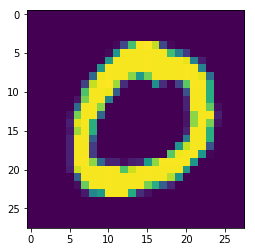

In [10]:
prediction=model.predict(test_data)
prediction=np.argmax(prediction,axis=1)
plt.imshow(test_data[111].reshape(28,28))
print('The predicted number is  '+str(prediction[111]))

# Submission for predicted model

In [11]:
imageid=[]
for x in range(1,28001):
    imageid.append(x)
submission=pd.DataFrame({'ImageId':imageid,'Label':prediction})
submission.to_csv('submission.csv',index=False)
submission

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3
...,...,...
27995,27996,9
27996,27997,7
27997,27998,3
27998,27999,9


# GUI application 

This is the code for GUI application that i have made for predicting numbers. I have used tkinter, PIL and imageio for this. GUI is nothing but a desktop app that provides you with an interface that helps you to interact with the computers and enriches your experience of giving a command to your code. PIL and imageio are used for opening, manipulating, and saving many different image file formats.

There is a canvas on which we can draw some random numbers and our PC will predict the number by the use of deep learning.

In [12]:
# from tkinter import *
# from PIL import ImageGrab
# import imageio
# import tkinter.font as font


# class Paint(object):
#     def __init__(self):
#         self.root=Tk()
#         self.root.title('Playing with numbers')
#         self.root.wm_iconbitmap('44143.ico')
#         self.root.configure(background='light salmon')
#         self.c=Canvas(self.root,bg='light cyan',height=330,width=400)
#         self.label=Label(self.root,text='Draw any numer',font=20,bg='light salmon')
#         self.label.grid(row=0,column=3)
#         self.c.grid(row=1,columnspan=9)
#         self.c.create_line(0,0,400,0,width=20,fill='midnight blue')
#         self.c.create_line(0,0,0,330,width=20,fill='midnight blue')
#         self.c.create_line(400,0,400,330,width=20,fill='midnight blue')
#         self.c.create_line(0,330,400,330,width=20,fill='midnight blue')
#         self.myfont=font.Font(size=20,weight='bold')
#         self.predicting_button=Button(self.root,text='Predict',fg='maroon',bg='steel blue',height=2,width=6,font=self.myfont,command=lambda:self.classify(self.c))
#         self.predicting_button.grid(row=2,column=1)
#         self.clear=Button(self.root,text='Clear',fg='blue',bg='red',height=2,width=6,font=self.myfont,command=self.clear)
#         self.clear.grid(row=2,column=5)
#         self.prediction_text = Text(self.root, height=5, width=5)
#         self.prediction_text.grid(row=4, column=3)
#         self.label=Label(self.root,text="Predicted Number is",fg="black",font=30,bg='light salmon')
        
#         self.label.grid(row=3,column=3)
#         self.model=model
#         self.setup()
#         self.root.mainloop()
#     def setup(self):
#         self.old_x=None
#         self.old_y=None
#         self.color='black'
#         self.linewidth=15
#         self.c.bind('<B1-Motion>', self.paint)
#         self.c.bind('<ButtonRelease-1>', self.reset)
#     def paint(self,event):
#         paint_color=self.color
#         if self.old_x and self.old_y:
#             self.c.create_line(self.old_x,self.old_y,event.x,event.y,fill=paint_color,width=self.linewidth,capstyle=ROUND,
#                               smooth=TRUE,splinesteps=48)
#         self.old_x=event.x
#         self.old_y=event.y
#     def clear(self):
#         """Clear drawing area"""
#         self.c.delete("all")

#     def reset(self, event):
#         """reset old_x and old_y if the left mouse button is released"""
#         self.old_x, self.old_y = None, None    
#     def classify(self,widget):
#         x=self.root.winfo_rootx()+widget.winfo_x()
#         y=self.root.winfo_rooty()+widget.winfo_y()
#         x1=widget.winfo_width()
#         y1=widget.winfo_height()
#         ImageGrab.grab().crop((x,y,x1,y1)).resize((28,28)).save('classify.png')
#         img=imageio.imread('classify.png',as_gray=False,pilmode='P')
#         img=np.array(img)
#         img=np.reshape(img,(1,28,28,1))
#         img[img==0] = 255
#         img[img==225] = 0
#         # Predict digit
#         pred = self.model.predict([img])
#         # Get index with highest probability
#         pred = np.argmax(pred)
#         print(pred)
#         self.prediction_text.delete("1.0", END)
#         self.prediction_text.insert(END, pred)
#         labelfont = ('times', 30, 'bold')
#         self.prediction_text.config(font=labelfont)
        
# if __name__ == '__main__':
#     Paint()